# GAAS Analysis Steps:

1. Calculate Transferability Matrix
2. Calculate Cos Similarity for each example
    
    a. Calc average for each model
    
3. Compare the adversarial subspace to Transferability Matrix

In [ ]:
import os
import numpy as np
import pickle
import torch
from robustbench import load_model
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# CIFAR-10 class names
CLASSES = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

MODELS = [
            "Bartoldson2024Adversarial_WRN-94-16", 
            "Amini2024MeanSparse_S-WRN-94-16",
            "Peng2023Robust",
            "Bai2024MixedNUTS",
            "Sehwag2021Proxy_ResNest152",
            "Gowal2021Improving_R18_ddpm_100m",
            "Debenedetti2022Light_XCiT-L12",
            "Sehwag2021Proxy_R18"
        ]

PERTURBED_DATA = [
    "data/targetedFGSM_perterbances/cifar10_Bartoldson2024Adversarial_WRN-94-16_WRN_94_16_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_amini2024meansparse_s-wrn-94-16_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_peng2023robust_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_bai2024mixednuts_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Sehwag2021Proxy_ResNest152_ResNest152_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Gowal2021Improving_R18_ddpm_100m_R18_ddpm_100m_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Debenedetti2022Light_XCiT-L12_XCiT_L12_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Sehwag2021Proxy_R18_R18_linf_eps8_adv.pt"
]

CAT_IDX = 3
DOG_IDX = 5
BINARY_CLASSES = {CAT_IDX: "cat", DOG_IDX: "dog"}

# L-inf threat-model budget (8/255 is the standard CIFAR-10 benchmark)
EPSILON = 8 / 255

print(f"Binary subset: {CAT_IDX}=cat  {DOG_IDX}=dog  epsilon={EPSILON:.5f}")

def pkl_save(a, path):
    with open(path, 'wb') as handle:
        pickle.dump(a, handle, protocol=pickle.HIGHEST_PROTOCOL)

def pkl_load(path):
    with open(path, 'rb') as handle:
        return pickle.load(handle)


/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Binary subset: 3=cat  5=dog  epsilon=0.03137


/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/robustbench/loaders.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Load all cat/dog data

In [3]:
# load n data pts, 2000 = all cat/dog pts
def build_catdog_dataset(n=2000):
    """Sample n Cat and Dog images from the CIFAR-10 test set."""
    ds         = datasets.CIFAR10(root="./data", train=False,
                                   download=True, transform=transforms.ToTensor())
    indices    = [i for i, (_, lbl) in enumerate(ds)
                  if lbl in (CAT_IDX, DOG_IDX)]
    np.random.seed(42)
    chosen     = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    loader     = DataLoader(Subset(ds, chosen),
                            batch_size=len(chosen), shuffle=False)
    imgs, lbls = next(iter(loader))
    return imgs, lbls
ci, cl       = build_catdog_dataset()
images = ci.to(device)
clean_labels = cl.to(device)
print(f"Sampled {len(clean_labels)} Cat/Dog images from test set.")

Sampled 2000 Cat/Dog images from test set.


# Setup functions for evaluating model on only cat/dog

In [4]:
def pred_model(m, images):
    # returns the predicted label of either cat or dog
    with torch.no_grad():
        out = m(images)

    pred = out[:, [CAT_IDX, DOG_IDX]].argmax(dim=1) # 0 = cat, 1 = dog
    pred[pred == 0] = CAT_IDX
    pred[pred == 1] = DOG_IDX

    return pred

# Load adversarial examples and get transferability matrix for each model.

In [5]:
#Load saved adversarial examples and perturbations from the files in experiment_configs
def torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)
    
perturbed_data = []
for perturbed_path in PERTURBED_DATA:
    perturbed_data.append(torch_load(perturbed_path))


In [7]:
t_matrix = np.zeros(shape=(len(MODELS), len(MODELS))) # transferability matrix, % of times fooled 
m = 0
for model_id in MODELS:
    print(model_id)
    loaded_model = load_model(model_name=model_id,
                            dataset="cifar10",
                            threat_model="Linf").to(device)
    loaded_model.eval()
    am = 0
    for x in perturbed_data:
        adv_image    = x['adv_images']
        clean_labels = x['clean_labels']

        adv_pred = pred_model(loaded_model, adv_image)
        adv_acc = (adv_pred != clean_labels).float().mean().item()
        t_matrix[m][am] = adv_acc
        am += 1
    del loaded_model # free memory, these models are like giga bytes large
    m+=1
    

Bartoldson2024Adversarial_WRN-94-16
Amini2024MeanSparse_S-WRN-94-16
Peng2023Robust
Bai2024MixedNUTS
The STD classifier has 232279184 parameters. 232279184 parameters are trainable.
The ROB classifier has 267240802 parameters. 267240802 parameters are trainable.
Using alpha=0.9987500602493457.
Using alpha_diffable=0.9570535356459247.
Bypassing robust base model nonlinear transformation for gradient calculations.
Disabling autocast.


/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/robustbench/model_zoo/architectures/mixing_net.py:237: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=enable_autocast):


Sehwag2021Proxy_ResNest152
Gowal2021Improving_R18_ddpm_100m
Debenedetti2022Light_XCiT-L12
Sehwag2021Proxy_R18


In [8]:
np.save('transfer_matrix', t_matrix)

In [20]:
def analyse_gaas_ex(A, B):
    # get both cos similarity and combined lengths of each example direction size
    i = 0
    ds = 0
    coss = 0
    for a, b in zip(A, B):
        ds += len(a) + len(b)
        if len(a) == 0 or len(b) == 0:
            continue
        a = np.array(a[0].cpu().view(-1).numpy())
        b = np.array(b[0].cpu().view(-1).numpy())
        a_n = a / (np.linalg.norm(a, keepdims=True) + 1e-8)
        b_n = b / (np.linalg.norm(b, keepdims=True) + 1e-8)
        cos = a_n @ b_n.T
        coss += np.mean(cos)
        i += 1

    return coss / i, ds / i, coss / len(A), ds / len(A)


gaas_stats = np.zeros(shape=(len(MODELS), len(MODELS), 4))
ai = 0
for ma in MODELS:
    print(ma)
    # load perturbance directions from A and B
    A = pkl_load(ma + '.pickle')

    bi = 0
    for mb in MODELS:
        print(mb)
        B = pkl_load(mb + '.pickle')
        gaas_stats[ai][bi] = analyse_gaas_ex(A, B)
        bi += 1
    ai += 1
    
np.save('gaas_overall_stats', gaas_stats)


Bartoldson2024Adversarial_WRN-94-16
Bartoldson2024Adversarial_WRN-94-16
Amini2024MeanSparse_S-WRN-94-16
Peng2023Robust
Bai2024MixedNUTS
Sehwag2021Proxy_ResNest152
Gowal2021Improving_R18_ddpm_100m
Debenedetti2022Light_XCiT-L12
Sehwag2021Proxy_R18
Amini2024MeanSparse_S-WRN-94-16
Bartoldson2024Adversarial_WRN-94-16
Amini2024MeanSparse_S-WRN-94-16
Peng2023Robust
Bai2024MixedNUTS
Sehwag2021Proxy_ResNest152
Gowal2021Improving_R18_ddpm_100m
Debenedetti2022Light_XCiT-L12
Sehwag2021Proxy_R18
Peng2023Robust
Bartoldson2024Adversarial_WRN-94-16
Amini2024MeanSparse_S-WRN-94-16
Peng2023Robust
Bai2024MixedNUTS
Sehwag2021Proxy_ResNest152
Gowal2021Improving_R18_ddpm_100m
Debenedetti2022Light_XCiT-L12
Sehwag2021Proxy_R18
Bai2024MixedNUTS
Bartoldson2024Adversarial_WRN-94-16
Amini2024MeanSparse_S-WRN-94-16
Peng2023Robust
Bai2024MixedNUTS
Sehwag2021Proxy_ResNest152
Gowal2021Improving_R18_ddpm_100m
Debenedetti2022Light_XCiT-L12
Sehwag2021Proxy_R18
Sehwag2021Proxy_ResNest152
Bartoldson2024Adversarial_WRN-94-

(8, 8, 4)


<Axes: >

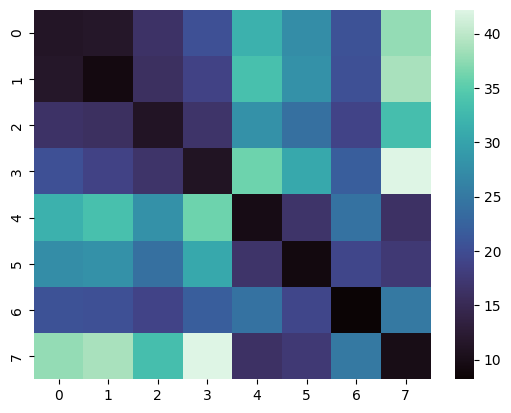

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sb
import pandas as pd

df = pd.DataFrame(gaas_stats[:, :, 0])
# fig, axes = plt.subplots(2, 2, figsize=(20, 20))
print(gaas_stats.shape)
im = sb.heatmap(df, vmax=1, cmap='magma')
# im = axes[0].imshow(gaas_stats[:, :, 0], aspect="auto", cmap="hot", vmax=1)
# plt.colorbar(im, ax=axes[0], label="Cosine similarity")
# sb.heatmap(gaas_stats[:, :, 1]/2, cmap='mako')

<Axes: >

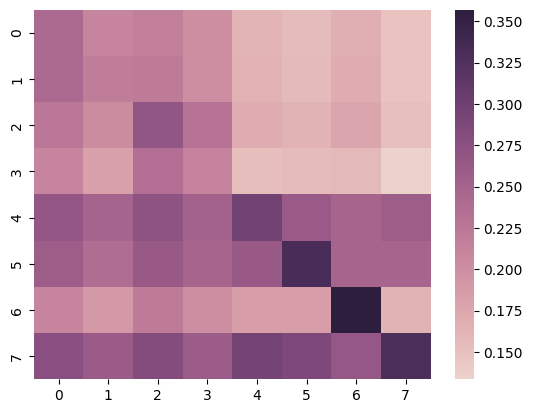

In [41]:
sb.heatmap(t_matrix, cmap=sb.cubehelix_palette(as_cmap=True))